In [1]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path.cwd().parent
PROCESSED_DIR = BASE_DIR / "data" / "processed"

df_fact_ticket = pd.read_csv(PROCESSED_DIR / "fact_ticket.csv")

In [2]:
df_fact_ticket.info()

<class 'pandas.DataFrame'>
RangeIndex: 154723 entries, 0 to 154722
Data columns (total 19 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   ticket_id       154723 non-null  str    
 1   customer_id     154723 non-null  int64  
 2   paying_method   154723 non-null  str    
 3   theater_name    154723 non-null  float64
 4   device_number   154723 non-null  str    
 5   original_price  154723 non-null  float64
 6   discount_value  154723 non-null  float64
 7   final_price     154723 non-null  float64
 8   time            154723 non-null  str    
 9   status_id       154723 non-null  int64  
 10  campaign_id     154723 non-null  int64  
 11  movie_name      154723 non-null  str    
 12  usergender      154723 non-null  str    
 13  dob             154723 non-null  str    
 14  campaign_type   154723 non-null  str    
 15  description     154723 non-null  str    
 16  error_group     154723 non-null  str    
 17  model           15472

In [3]:
df_fact_ticket["dob"] = pd.to_datetime(df_fact_ticket["dob"], errors="coerce")
df_fact_ticket["time"] = pd.to_datetime(df_fact_ticket["time"], errors="coerce")

# Age distribution

In [20]:
today = pd.Timestamp.today().normalize()

df_fact_ticket["age"] = (
    (today - df_fact_ticket["dob"]).dt.days / 365.25
).round(0)

In [27]:
df_customer_analysis = df_fact_ticket[["age", "usergender"]].copy()

In [33]:
df_customer_analysis.head(5)

,age,usergender
0,37.0,Male
1,35.0,Male
2,37.0,Male
3,29.0,Male
4,38.0,Male


In [30]:
df_customer_analysis["usergender"].value_counts(dropna=False)

usergender
Female        71421
Male          67558
Not verify    15744
Name: count, dtype: int64

In [31]:
pd.crosstab(df_customer_analysis["age"], df_customer_analysis["usergender"])

usergender,Female,Male,Not verify
age,,,
7.0,0,1,0
8.0,3,5,0
9.0,1,2,0
10.0,1,4,0
11.0,2,0,0
...,...,...,...
110.0,1,1,0
111.0,2,6,0
112.0,2,4,0


In [32]:
df_customer_analysis[df_customer_analysis["usergender"] == "Not verify"]["age"].value_counts().head(20)

age
56.0    13956
31.0      164
30.0      150
28.0      147
33.0      138
32.0      136
34.0      131
29.0      125
27.0      111
36.0       99
35.0       99
26.0       77
37.0       69
46.0       53
38.0       43
39.0       38
25.0       35
42.0       25
43.0       17
40.0       17
Name: count, dtype: int64

In [34]:
df_fact_ticket.loc[
    df_fact_ticket["usergender"] == "Not verify",
    "dob"
].value_counts().head(20)

dob
1970-01-01    13951
1980-01-01       42
1990-01-01       27
1998-10-18        8
1998-07-07        8
1991-01-01        8
1987-01-01        7
1997-12-26        7
1996-06-03        7
1990-10-22        6
1989-10-04        6
1995-01-28        6
1995-05-06        5
1996-11-28        5
1993-11-26        5
1996-10-11        5
1991-08-25        5
1992-09-22        5
1993-02-20        5
1996-10-05        5
Name: count, dtype: int64

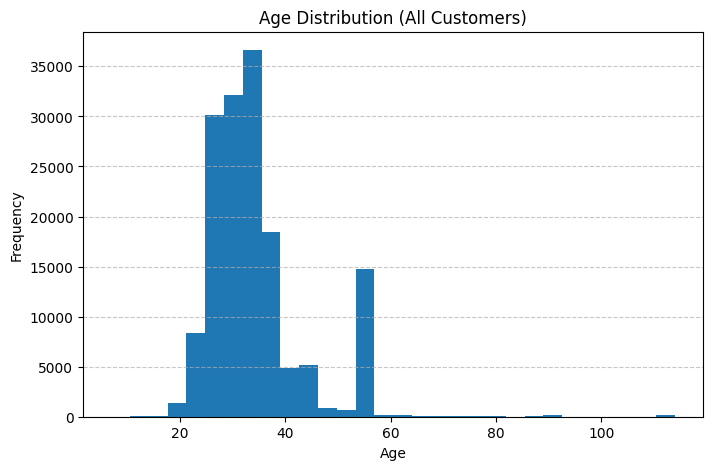

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df_customer_analysis["age"].plot(kind="hist", bins=30)

plt.title("Age Distribution (All Customers)")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

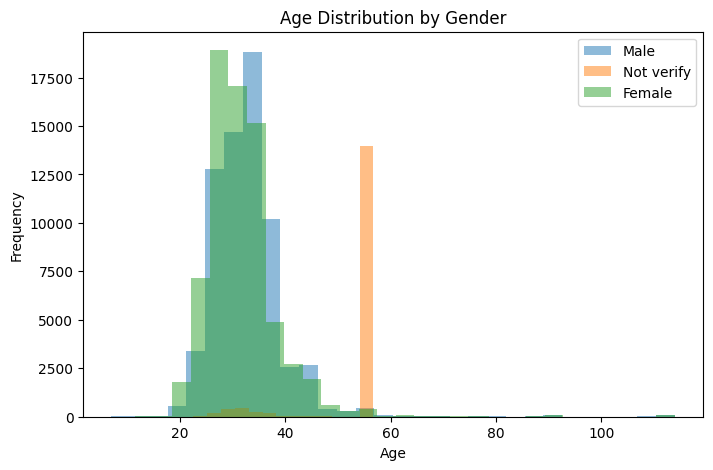

In [36]:
plt.figure(figsize=(8,5))

for gender in df_customer_analysis["usergender"].unique():
    subset = df_customer_analysis[df_customer_analysis["usergender"] == gender]
    subset["age"].plot(kind="hist", bins=30, alpha=0.5, label=gender)

plt.legend()
plt.title("Age Distribution by Gender")

plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

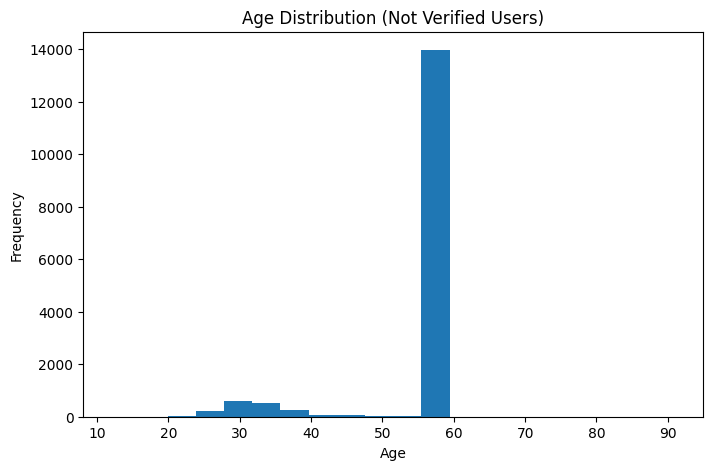

In [37]:
plt.figure(figsize=(8,5))

df_customer_analysis[
    df_customer_analysis["usergender"] == "Not verify"
]["age"].plot(kind="hist", bins=20)

plt.title("Age Distribution (Not Verified Users)")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

In [38]:
df_customer_analysis["age_group"] = pd.cut(
    df_customer_analysis["age"],
    bins=[0, 17, 24, 34, 44, 54, 100],
    labels=["<18", "18-24", "25-34", "35-44", "45-54", "55+"]
)

In [39]:
age_group_count = df_customer_analysis["age_group"].value_counts().sort_index()
age_group_count

age_group
<18        181
18-24     9706
25-34    91462
35-44    32628
45-54     5036
55+      15501
Name: count, dtype: int64

In [40]:
age_group_pct = (
    df_customer_analysis["age_group"]
    .value_counts(normalize=True)
    .sort_index() * 100
).round(2)

age_group_pct

age_group
<18       0.12
18-24     6.28
25-34    59.19
35-44    21.12
45-54     3.26
55+      10.03
Name: proportion, dtype: float64

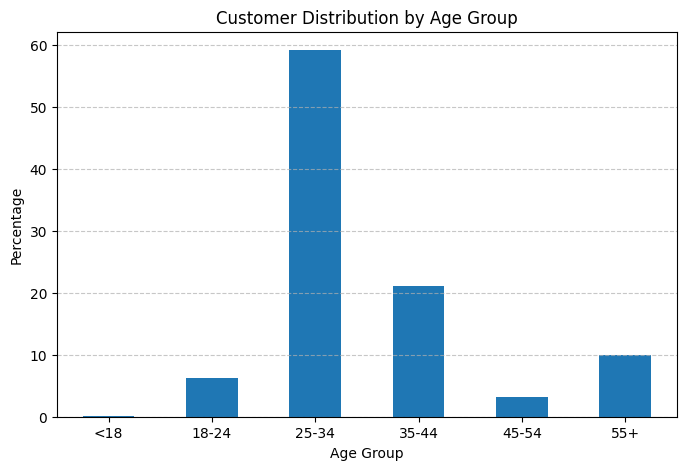

In [41]:
plt.figure(figsize=(8,5))

age_group_pct.plot(kind="bar")

plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Percentage")

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

1. Core Age Segment
The age distribution shows a strong concentration of users between 25 and 34 years old, accounting for the majority of the customer base.

This indicates that the platform primarily attracts young adults, who represent the core target audience.

2. Data Anomaly Detection
An unusual spike was observed at age 56 in the overall age distribution.

Further analysis revealed that this spike is predominantly associated with users labeled as "Not verify" in the gender field.

3. Root Cause Identification
A deeper investigation suggests that these records are likely generated from a default or placeholder date of birth rather than actual user input.

Therefore, the age value of 56 does not represent real customer behavior but rather a data quality issue.
4. Data Quality Implication
The presence of a significant number of "Not verify" users highlights a limitation in user data collection.

This may affect the reliability of demographic analysis and suggests a need for improving data validation or user onboarding processes.

5. Refined Customer Profile
After excluding invalid records, the age distribution becomes more consistent and realistic, confirming that the platform mainly serves younger users, particularly those in the 25–34 age group.

6. Business-Relevant Conclusion
Overall, the platform is strongly aligned with a young adult audience, which fits well with its focus on entertainment services such as movie ticket booking.

This insight can be leveraged to optimize marketing strategies, content targeting, and user engagement initiatives